<a href="https://colab.research.google.com/github/saranyasubramaniam9787-ship-it/Product-Shipment-and-Logistics-Performance-Analysis/blob/main/Main_Project_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Product Shipment and Logistics Performance Analysis





**Project Problem Statement**

- Analyze shipment performance and delivery delays across different regions and shipping modes.
- Compare scheduled delivery time with actual delivery time to measure shipment efficiency.
- Identify regions with high late delivery risk and logistics challenges.
- Evaluate the efficiency of different shipping modes used in apparel logistics operations.
- Analyze the relationship between logistics operations, sales performance, and profitability.
- Discover top-performing apparel categories and high-demand markets based on shipment data.
- Monitor delivery status and identify patterns in delayed, cancelled, and completed shipments.
- Analyze monthly and seasonal shipment trends to understand logistics demand patterns.
- Analyze the contribution of different customer segments to overall sales.
- Evaluate customer payment behavior through transaction type analysis


**Outcome**
- Improved understanding of apparel shipment performance, delivery delays, and logistics efficiency across different regions and shipping modes.
- Enabled data-driven decision-making by identifying high-risk delivery areas, optimizing shipping operations, and improving overall supply chain performance.

**Domain**

E-commerce

**Dataset Information**

source:https://data.mendeley.com/datasets/kfzvv8bfgr/1

Year / Timeline: Data collected during 2015 to 2018

Dataset Column/features Description:

- Transaction Type: The nature or category of the transaction, such as credit, debit, or cash

- Days for shipping (real): Actual number of days taken to ship the order

- Days for shipment (scheduled): Planned or promised number of days for shipment

- Delivery Status: Current status of the delivery (e.g., delivered, pending, canceled)

- Late_delivery_risk: Indicates whether the order is at risk of being delivered late

- Category Name: Product category or classification

- Customer City: City where the customer is located

- Customer Segment: Customer classification segment (e.g., consumer, corporate, home office)

- Customer State: State or province where the customer resides

- Latitude: Geographic latitude coordinate of the customer location

- Longitude: Geographic longitude coordinate of the customer location

- Market: Regional market or sales region (e.g., APAC, EU, LATAM)

- Order City: City where the order was placed or processed

- Order Country: Country where the order was placed

- order date (DateOrders): Date when the order was created or placed

- Order Id: Unique identifier for each order

- Order Item Profit Ratio: Profit margin ratio for the specific order item

- Order Item Quantity: Number of units of the product ordered

- Sales: Total sales amount for the order item

- Order Item Total: Total value for the specific order item (quantity × price)

- Order Profit Per Order: Total profit generated from the entire order

- Order Region: Geographic region where the order was processed

- Order Status: Current processing status of the order (e.g., complete, pending, shipped)

- Product Name: Name or title of the product ordered

- Product Price: Unit price of the product

- shipping date (DateOrders): Date when the order was shipped

- Shipping Mode: Method of shipment used (e.g., standard,same day)



**Problem Definition and Dataset Selection**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("https://github.com/saranyasubramaniam9787-ship-it/Final-Project---Apparel-Shipment-and-Logistics-Performance-Analytics/raw/refs/heads/main/DataCoSupplyChainDataset-uncleaned_dataset.zip",encoding='latin1')

In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,02-03-2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [ ]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [ ]:
df.shape

(180519, 53)

In [ ]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
180514,False
180515,False
180516,False
180517,False


In [ ]:
row,column = df.shape
print(row)
print(column)

180519
53


In [ ]:
df.rename(columns={'Type':'Transaction Type'},inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Transaction Type', 'Days for shipping (real)',
       'Days for shipment (scheduled)', 'Benefit per order',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Id', 'Category Name', 'Customer City', 'Customer Country',
       'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname',
       'Customer Password', 'Customer Segment', 'Customer State',
       'Customer Street', 'Customer Zipcode', 'Department Id',
       'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City',
       'Order Country', 'Order Customer Id', 'order date (DateOrders)',
       'Order Id', 'Order Item Cardprod Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id',
       'Product Category Id',

In [ ]:
df.drop(columns=['Benefit per order','Sales per customer','Category Id','Customer Country','Customer Email','Customer Password','Customer Street', 'Customer Zipcode', 'Department Id','Order Item Cardprod Id','Order Zipcode','Product Card Id','Product Category Id','Product Description','Product Description','Customer Id','Department Name','Order Customer Id','Order State','Order Item Product Price','Order Item Id','Product Status','Customer Fname', 'Customer Lname','Order Item Discount','Order Item Discount Rate','Product Image'],inplace=True)

In [ ]:
df.columns

Index(['Transaction Type', 'Days for shipping (real)',
       'Days for shipment (scheduled)', 'Delivery Status',
       'Late_delivery_risk', 'Category Name', 'Customer City',
       'Customer Segment', 'Customer State', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'order date (DateOrders)', 'Order Id',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order Status', 'Product Name', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='object')

In [ ]:
df.shape

(180519, 27)

In [ ]:
df[['Order Item Profit Ratio', 'Order Item Quantity','Sales','Order Item Total', 'Order Profit Per Order']].head(5)

,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order
0,0.29,1,327.75,314.640015,91.250000
1,-0.80,1,327.75,311.359985,-249.089996
2,-0.80,1,327.75,309.720001,-247.779999
3,0.08,1,327.75,304.809998,22.860001
4,0.45,1,327.75,298.250000,134.210007


In [ ]:
df.isnull().sum()

,0
Transaction Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Delivery Status,0
Late_delivery_risk,0
Category Name,0
Customer City,0
Customer Segment,0
Customer State,0
Latitude,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Transaction Type               180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Delivery Status                180519 non-null  object 
 4   Late_delivery_risk             180519 non-null  int64  
 5   Category Name                  180519 non-null  object 
 6   Customer City                  180519 non-null  object 
 7   Customer Segment               180519 non-null  object 
 8   Customer State                 180519 non-null  object 
 9   Latitude                       180519 non-null  float64
 10  Longitude                      180519 non-null  float64
 11  Market                         180519 non-null  object 
 12  Order City                    

In [ ]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'],   format='mixed')

In [ ]:
df['shipping date (DateOrders)']=pd.to_datetime(df['shipping date (DateOrders)'],format='mixed')

In [ ]:
df.rename(columns={'Late_delivery_risk':'Late delivery risk','order date (DateOrders)':'order date','shipping date (DateOrders)':'shipping date','Sales':'Sales price'},inplace=True)

In [ ]:
df.columns

Index(['Transaction Type', 'Days for shipping (real)',
       'Days for shipment (scheduled)', 'Delivery Status',
       'Late delivery risk', 'Category Name', 'Customer City',
       'Customer Segment', 'Customer State', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'order date', 'Order Id',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales price',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order Status', 'Product Name', 'Product Price', 'shipping date',
       'Shipping Mode'],
      dtype='object')

In [ ]:
df.columns=(df.columns.str.title())

In [ ]:
df.columns

Index(['Transaction Type', 'Days For Shipping (Real)',
       'Days For Shipment (Scheduled)', 'Delivery Status',
       'Late Delivery Risk', 'Category Name', 'Customer City',
       'Customer Segment', 'Customer State', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Date', 'Order Id',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales Price',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order Status', 'Product Name', 'Product Price', 'Shipping Date',
       'Shipping Mode'],
      dtype='object')

In [ ]:
df['Transaction Type']=df['Transaction Type'].str.title()

In [ ]:
for All_col in df.select_dtypes(include='object').columns:
  df[All_col]=df[All_col].str.title()


In [ ]:
df.head(5)

,Transaction Type,Days For Shipping (Real),Days For Shipment (Scheduled),Delivery Status,Late Delivery Risk,Category Name,Customer City,Customer Segment,Customer State,Latitude,...,Order Item Quantity,Sales Price,Order Item Total,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,Shipping Date,Shipping Mode
0,Debit,3,4,Advance Shipping,0,Sporting Goods,Caguas,Consumer,Pr,18.251453,...,1,327.75,314.640015,91.250000,Southeast Asia,Complete,Smart Watch,327.75,2018-02-03 22:56:00,Standard Class
1,Transfer,5,4,Late Delivery,1,Sporting Goods,Caguas,Consumer,Pr,18.279451,...,1,327.75,311.359985,-249.089996,South Asia,Pending,Smart Watch,327.75,2018-01-18 12:27:00,Standard Class
2,Cash,4,4,Shipping On Time,0,Sporting Goods,San Jose,Consumer,Ca,37.292233,...,1,327.75,309.720001,-247.779999,South Asia,Closed,Smart Watch,327.75,2018-01-17 12:06:00,Standard Class
3,Debit,3,4,Advance Shipping,0,Sporting Goods,Los Angeles,Home Office,Ca,34.125946,...,1,327.75,304.809998,22.860001,Oceania,Complete,Smart Watch,327.75,2018-01-16 11:45:00,Standard Class
4,Payment,2,4,Advance Shipping,0,Sporting Goods,Caguas,Corporate,Pr,18.253769,...,1,327.75,298.250000,134.210007,Oceania,Pending_Payment,Smart Watch,327.75,2018-01-15 11:24:00,Standard Class


In [ ]:
df['Customer State'].unique()

array(['Pr', 'Ca', 'Ny', 'Fl', 'Ma', 'Il', 'Mt', 'Pa', 'Mi', 'Tx', 'De',
       'Ga', 'Md', 'Oh', 'Hi', 'Nj', 'Wi', 'Az', 'Co', 'Mn', 'Nc', 'Nm',
       'Or', 'Sc', 'Va', 'Ut', 'Wa', 'Ky', 'Wv', 'Ri', 'Ct', 'La', 'Tn',
       'Dc', 'Nd', 'Mo', 'In', 'Id', 'Nv', 'Ks', 'Ar', 'Ok', 'Al', 'Ia',
       '95758', '91732'], dtype=object)

In [ ]:
df["Customer State"] = df["Customer State"].replace(
    {
        "Pr": "Puerto Rico",
        "Ca": "California",
        "Ny": "New York",
        "Fl": "Florida",
        "Ma": "Massachusetts",
        "Il": "Illinois",
        "Mt": "Montana",
        "Pa": "Pennsylvania",
        "Mi": "Michigan",
        "Tx": "Texas",
        "De": "Delaware",
        "Ga": "Georgia",
        "Md": "Maryland",
        "Oh": "Ohio",
        "Hi": "Hawaii",
        "Nj": "New Jersey",
        "Wi": "Wisconsin",
        "Az": "Arizona",
        "Co": "Colorado",
        "Mn": "Minnesota",
        "Nc": "North Carolina",
        "Nm": "New Mexico",
        "Or": "Oregon",
        "Sc": "South Carolina",
        "Va": "Virginia",
        "Ut": "Utah",
        "Wa": "Washington",
        "Ky": "Kentucky",
        "Wv": "West Virginia",
        "Ri": "Rhode Island",
        "Ct": "Connecticut",
        "La": "Louisiana",
        "Tn": "Tennessee",
        "Dc": "Washington D.C.",
        "Nd": "North Dakota",
        "Mo": "Missouri",
        "In": "Indiana",
        "Id": "Idaho",
        "Nv": "Nevada",
        "Ks": "Kansas",
        "Ar": "Arkansas",
        "Ok": "Oklahoma",
        "Al": "Alabama",
        "Ia": "Iowa",
    }
)


In [ ]:
rows_to_drop=df[df['Customer State'].isin(['95758', '91732'])].index

In [ ]:
df.drop(rows_to_drop,inplace=True)

In [ ]:
df['Customer State'].unique()

array(['Puerto Rico', 'California', 'New York', 'Florida',
       'Massachusetts', 'Illinois', 'Montana', 'Pennsylvania', 'Michigan',
       'Texas', 'Delaware', 'Georgia', 'Maryland', 'Ohio', 'Hawaii',
       'New Jersey', 'Wisconsin', 'Arizona', 'Colorado', 'Minnesota',
       'North Carolina', 'New Mexico', 'Oregon', 'South Carolina',
       'Virginia', 'Utah', 'Washington', 'Kentucky', 'West Virginia',
       'Rhode Island', 'Connecticut', 'Louisiana', 'Tennessee',
       'Washington D.C.', 'North Dakota', 'Missouri', 'Indiana', 'Idaho',
       'Nevada', 'Kansas', 'Arkansas', 'Oklahoma', 'Alabama', 'Iowa'],
      dtype=object)

Before Treating Outliers

In [ ]:
colus=['Days For Shipping (Real)','Days For Shipment (Scheduled)','Order Item Quantity','Sales Price','Product Price','Order Item Profit Ratio','Order Profit Per Order']

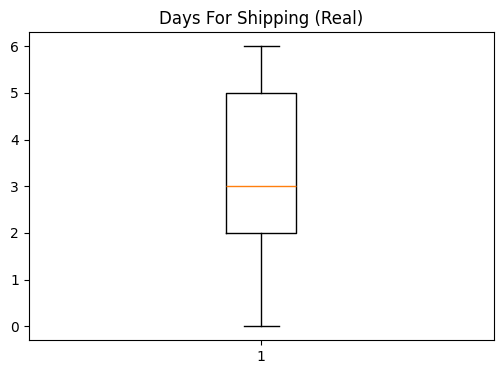

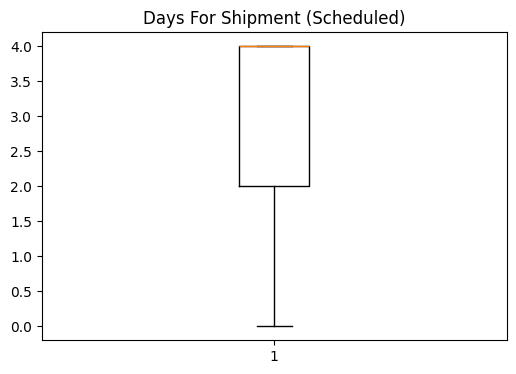

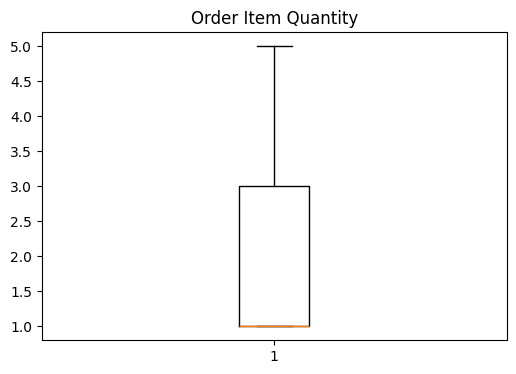

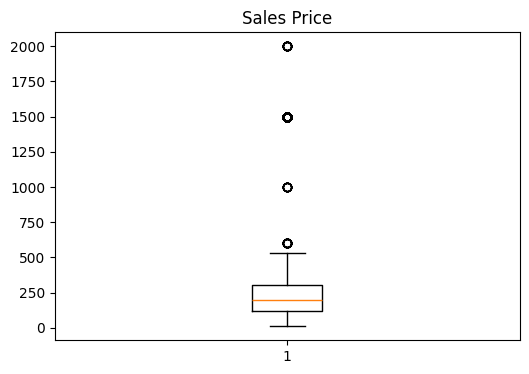

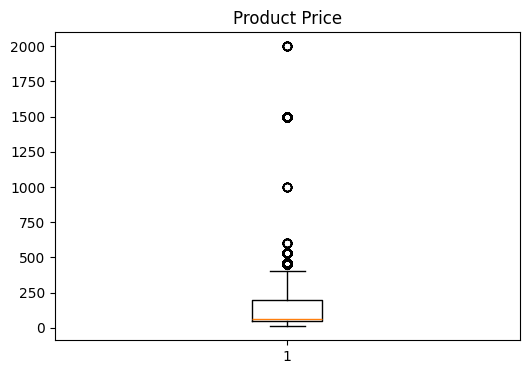

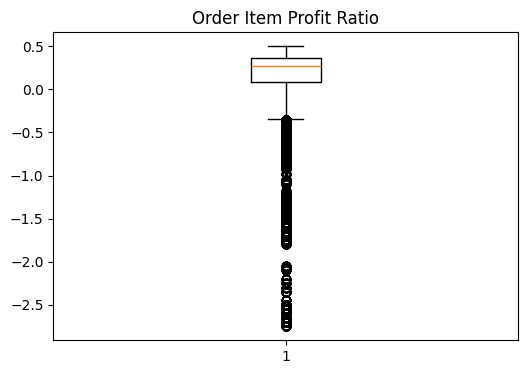

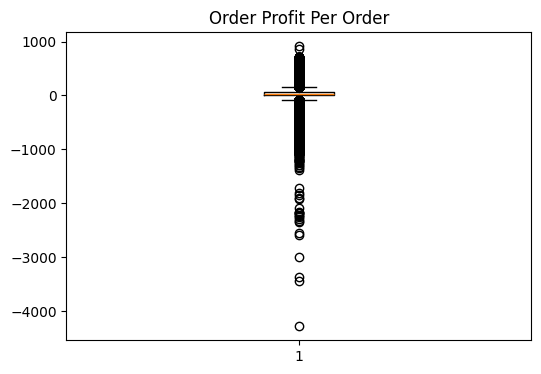

In [ ]:
for col in colus:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

- In the original business data, it is natural for customers to purchase products with different price ranges. For example, one customer may buy a product worth ₹100, while another may buy a laptop worth ₹10,000 or more. These are valid business transactions and should not be treated as data errors.
- Since the objective of this project is Logistics and Shipment Analysis, the focus is on understanding shipping performance, delivery delays, shipment risks, and their impact on business outcomes.
- Although outliers were present in sales price,order item profit ratio,order profit per order columns, completely removing them using the IQR method was not preferred because it would result in the loss of genuine business records and potentially valuable information.

In [ ]:
df[['Days For Shipping (Real)','Days For Shipment (Scheduled)','Order Item Quantity','Sales Price','Product Price','Order Item Profit Ratio','Order Profit Per Order']].describe()

,Days For Shipping (Real),Days For Shipment (Scheduled),Order Item Quantity,Sales Price,Product Price,Order Item Profit Ratio,Order Profit Per Order
count,180516.000000,180516.000000,180516.000000,180516.000000,180516.000000,180516.000000,180516.000000
mean,3.497657,2.931845,2.127656,203.771883,141.231298,0.120644,21.974593
std,1.623731,1.374449,1.453456,132.273070,139.732278,0.466799,104.434300
min,0.000000,0.000000,1.000000,9.990000,9.990000,-2.750000,-4274.979980
25%,2.000000,2.000000,1.000000,119.980003,50.000000,0.080000,7.000000
50%,3.000000,4.000000,1.000000,199.919998,59.990002,0.270000,31.520000
75%,5.000000,4.000000,3.000000,299.950012,199.990005,0.360000,64.800003
max,6.000000,4.000000,5.000000,1999.989990,1999.989990,0.500000,911.799988


- Instead, Percentile Capping was applied to treat extreme values while retaining all observations in the dataset.
- This approach helped:
- Preserve the original number of records.
- Retain important business transactions.
- Reduce the influence of extreme values on the analysis.
- Prevent distortion in statistical measures and visualizations.
- Maintain data integrity for shipment and logistics-related insights.


In [ ]:
for col in ["Order Profit Per Order", "Order Item Profit Ratio"]:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)


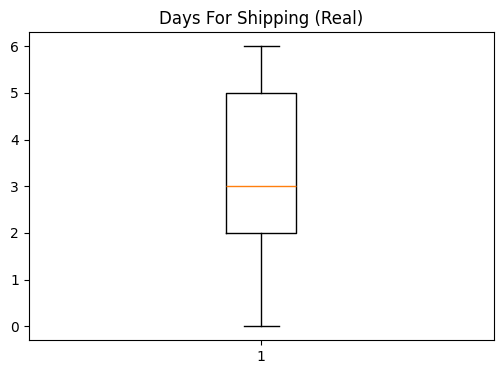

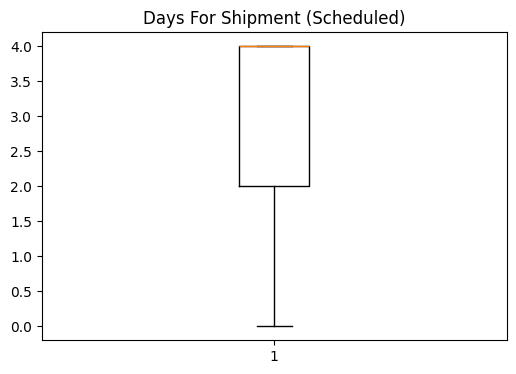

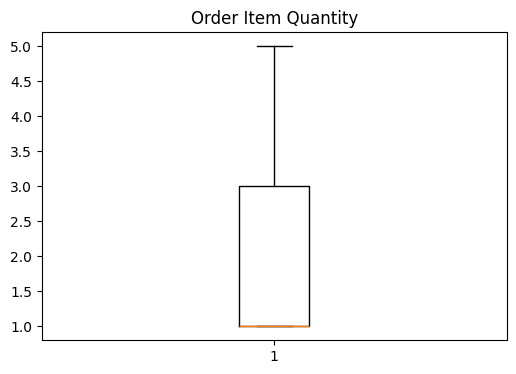

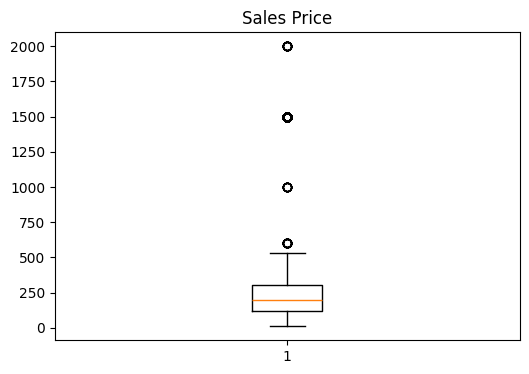

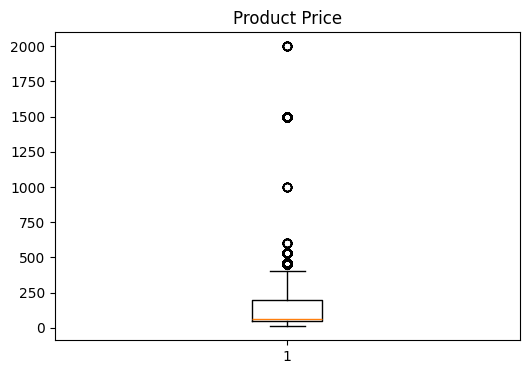

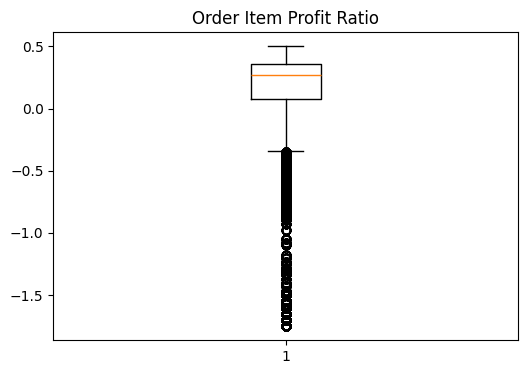

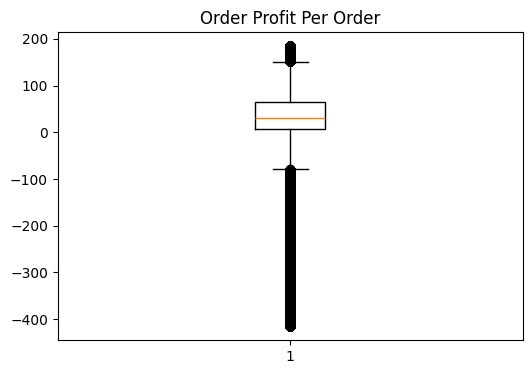

In [ ]:
for col in colus:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

- Log Transformation was also considered; however, Percentile Capping was chosen because it preserves the original scale of the data and makes business interpretation easier.
- By using Percentile Capping, the analysis remains focused on logistics and shipment performance while minimizing the impact of extreme values without losing important business information.
- Therefore, this method provided a balanced approach between outlier treatment and business relevance, ensuring that the final insights remain meaningful and actionable.

In [ ]:
colus = [
    "Days For Shipping (Real)",
    "Days For Shipment (Scheduled)",
    "Order Item Quantity",
    "Sales Price",
    "Product Price",
    "Order Item Profit Ratio",
    "Order Profit Per Order",
]
skewness= df[colus].skew()
print(skewness)


Days For Shipping (Real)         0.084770
Days For Shipment (Scheduled)   -0.731999
Order Item Quantity              0.880227
Sales Price                      2.884304
Product Price                    3.191093
Order Item Profit Ratio         -2.500332
Order Profit Per Order          -2.284690
dtype: float64


##**visualization and insights**

**1.Analyze shipment performance and delivery delays across different regions and shipping modes.**

In [ ]:
print(df['Delivery Status'].value_counts())
df.groupby('Delivery Status')['Order Region'].value_counts().head(10)


Delivery Status
Late Delivery        98976
Advance Shipping     41592
Shipping On Time     32194
Shipping Canceled     7754
Name: count, dtype: int64


Delivery Status   Order Region   
Advance Shipping  Central America    6566
                  Western Europe     6138
                  South America      3476
                  Northern Europe    2341
                  Oceania            2324
                  Southern Europe    2246
                  Southeast Asia     2208
                  Caribbean          1997
                  West Of Usa        1835
                  South Asia         1765
Name: count, dtype: int64

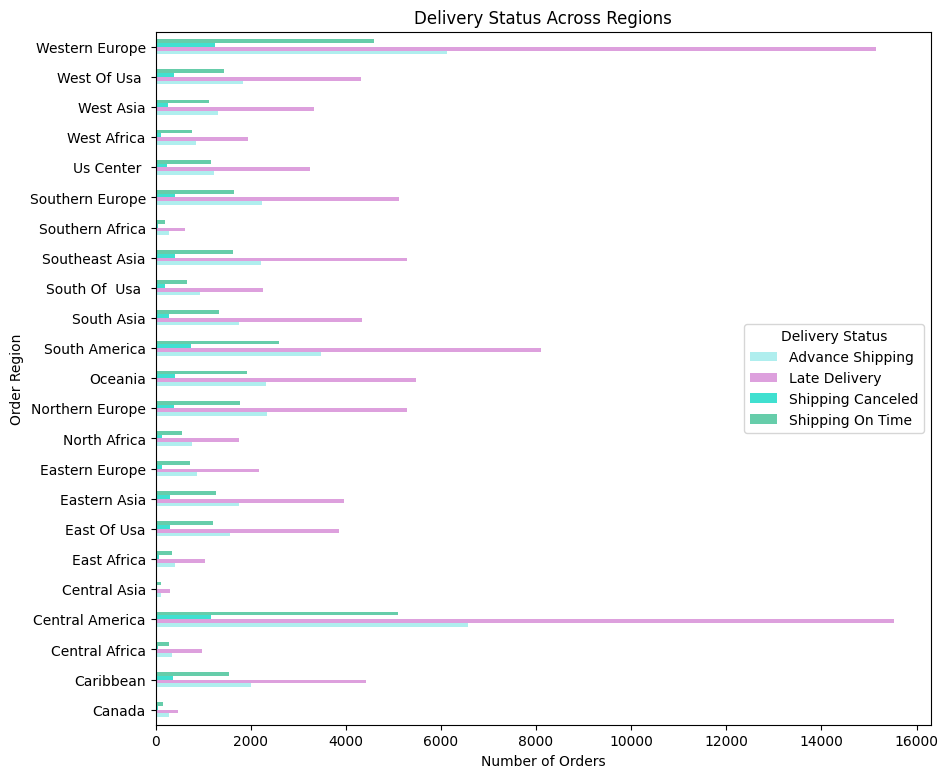

In [ ]:
pd.crosstab(df['Order Region'],df['Delivery Status']).plot(kind='barh',stacked=False,figsize=(10,9),color=['paleturquoise','plum','turquoise','mediumaquamarine'])
plt.title('Delivery Status Across Regions')
plt.xlabel('Number of Orders')
plt.ylabel('Order Region')
plt.show()


**INSIGHTS:**
- Central America and Western Europe handle the highest shipment volumes compared to other regions.
- Shipping Cancellations are relatively low across regions, suggesting that most orders are successfully fulfilled despite delivery delays.
- Longer shipping distances and multiple transit points in international regions may contribute to higher late-delivery occurrences.
- The large gap between Late Deliveries and On-Time Deliveries indicates inefficiencies in shipment scheduling or carrier performance.
- If current shipment patterns continue, high-volume regions are likely to experience increasing delivery delays as order demand grows.
- Persistent delivery delays may negatively impact customer satisfaction and retention in affected regions.
- Focus delay-reduction strategies on high-volume regions such as Central America and Western Europe.
- Implement region-wise delivery performance monitoring to identify and address recurring delay issues proactively.

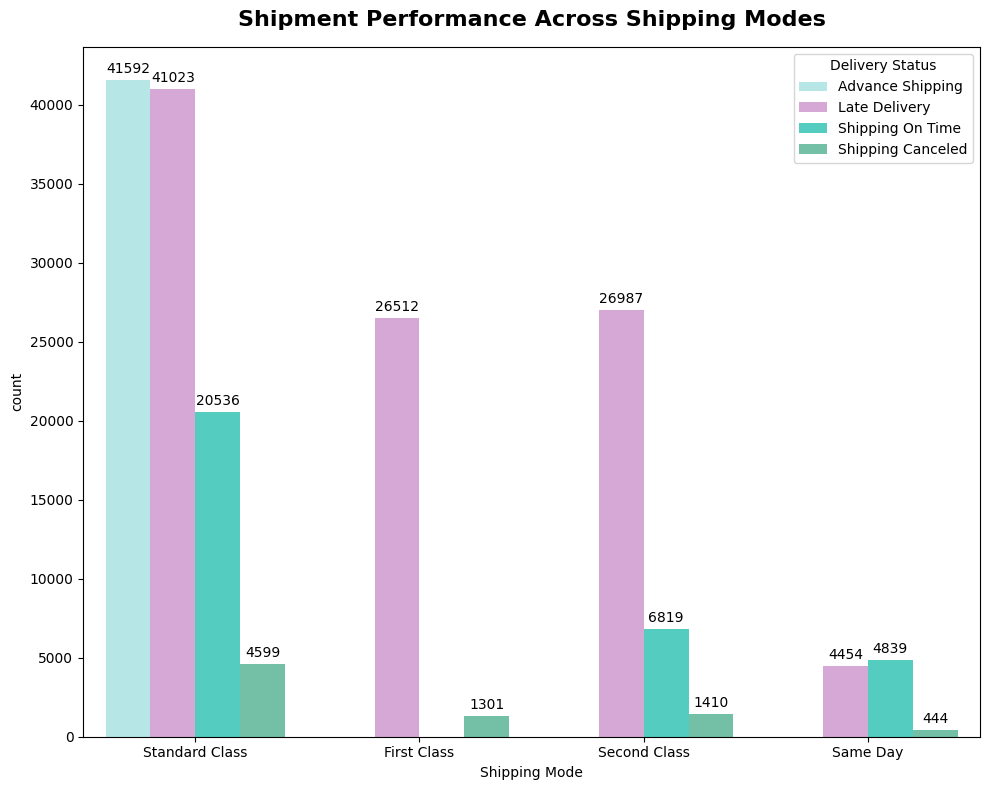

In [ ]:

plt.figure(figsize=(10, 8))
ax = sns.countplot(data=df,x='Shipping Mode',hue='Delivery Status',
    palette=['paleturquoise', 'plum', 'turquoise', 'mediumaquamarine'])

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)
plt.title('Shipment Performance Across Shipping Modes', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


**INSIGHTS:**
- Standard Class handles the highest shipment volume among all shipping modes.
- Late Deliveries are significantly higher than On-Time Deliveries across all shipping modes.
- The high usage of Standard Class contributes to a larger number of delivery delays.
- First Class and Second Class shipments also experience considerable delays, indicating operational inefficiencies beyond shipping speed.
- If current trends continue, Standard Class will remain the primary contributor to overall delivery delays.
- Increasing shipment volumes without process improvements may further impact delivery performance.
- Improve logistics planning and carrier coordination for Standard Class shipments.
- Investigate the causes of delays in First Class and Second Class services despite their premium nature.

**2. Compare scheduled delivery days with actual delivery days to measure shipment efficiency.**

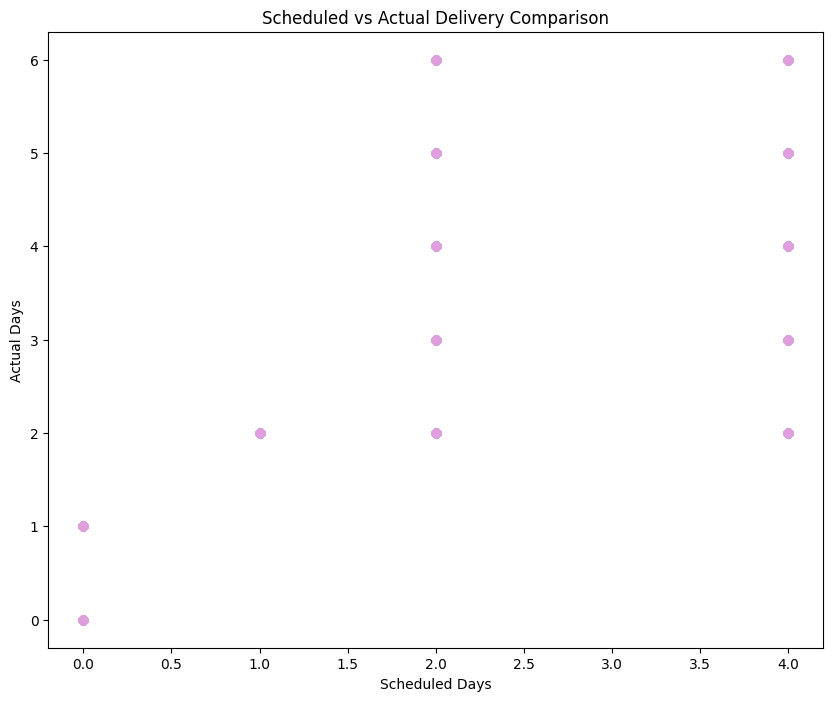

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(df['Days For Shipment (Scheduled)'],df['Days For Shipping (Real)'],color='plum')
plt.xlabel('Scheduled Days')
plt.ylabel('Actual Days')
plt.title('Scheduled vs Actual Delivery Comparison')
plt.show()

**INSIGHTS:**
- The actual delivery time is usually longer than the scheduled delivery time.
- Orders scheduled for 2 days show the highest variation in delivery time, ranging from 2 to 6 days.
- Delays in 2-day shipments may be caused by congestion at distribution hubs or transit centers.
- Orders scheduled for 0–1 day delivery are more likely to arrive on time.
- Shipments scheduled for 2 days or more are often delivered 2–4 days later than planned.
- Shipments scheduled for 4 days typically experience an additional delay of 2–3 days.
- Adding buffer time to schedules of 2 days or more can improve delivery accuracy.

In [ ]:
df['Delay Days']=(df['Days For Shipping (Real)']-df['Days For Shipment (Scheduled)'])

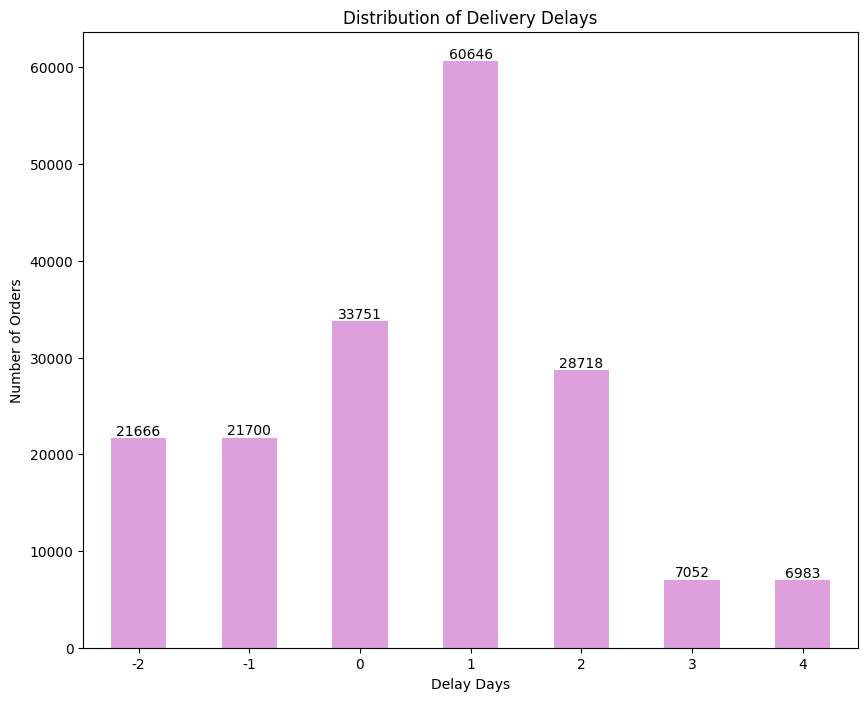

In [ ]:
plt.figure(figsize=(10,8))
a=df['Delay Days'].value_counts().sort_index().plot(kind='bar',color='plum')
for c in a.containers:
  a.bar_label(c)
plt.title('Distribution of Delivery Delays')
plt.xlabel('Delay Days')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

**INSIGHTS:**
- Most shipments are delivered within 0 to 1 day of the scheduled delivery date, indicating generally efficient delivery performance.
- Both early deliveries(-2,-1) and delayed deliveries exist, but the highest concentration of shipments is around the planned schedule.
- The small gap between scheduled and actual delivery days suggests that shipment planning is largely effective.
- Deliveries delayed by 2–4 days indicate occasional operational or transportation inefficiencies.
- Future shipments are likely to continue arriving close to their scheduled delivery dates.
- Without process improvements, a portion of shipments may continue to experience delays of more than 2 days.
- Focus on reducing shipments delayed by 2 or more days through better route and carrier management.
- Track the difference between scheduled and actual delivery days regularly to improve delivery accuracy.

**3. Identify regions with high late delivery risk and logistics challenges.**

In [ ]:
df.columns

Index(['Transaction Type', 'Days For Shipping (Real)',
       'Days For Shipment (Scheduled)', 'Delivery Status',
       'Late Delivery Risk', 'Category Name', 'Customer City',
       'Customer Segment', 'Customer State', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Date', 'Order Id',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales Price',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order Status', 'Product Name', 'Product Price', 'Shipping Date',
       'Shipping Mode', 'Delay Days'],
      dtype='object')

In [ ]:
df[['Order Region','Late Delivery Risk']]

,Order Region,Late Delivery Risk
0,Southeast Asia,0
1,South Asia,1
2,South Asia,0
3,Oceania,0
4,Oceania,0
...,...,...
180514,Eastern Asia,0
180515,Eastern Asia,1
180516,Oceania,1
180517,Oceania,0


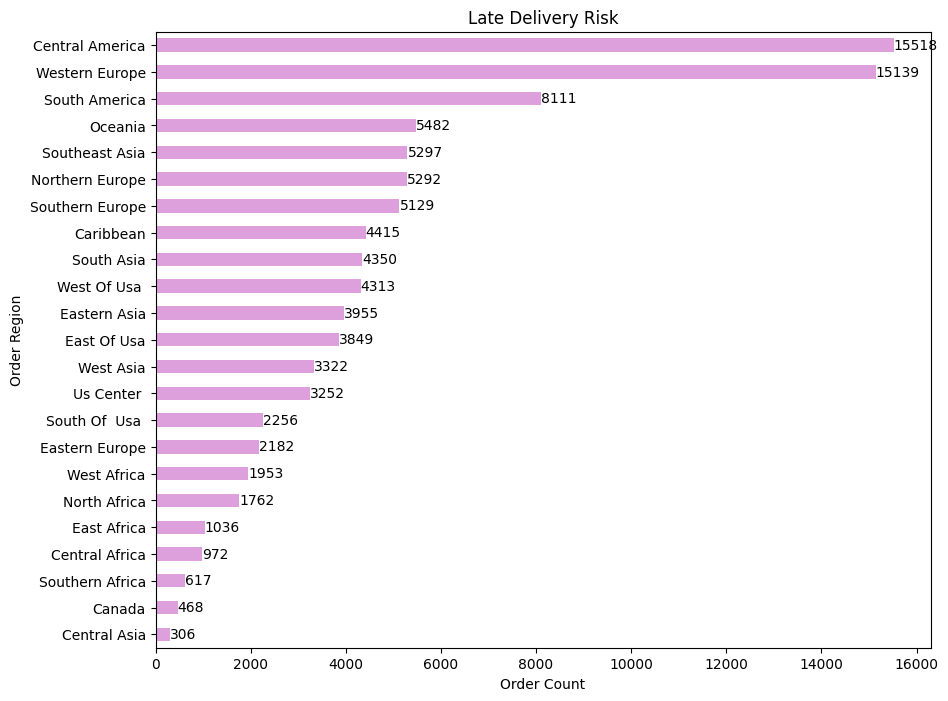

In [ ]:
b=df.groupby('Order Region')['Late Delivery Risk'].sum().sort_values().plot(kind='barh',figsize=(10,8),color=['plum'])
for c in b.containers:
  b.bar_label(c)
plt.title('Late Delivery Risk')
plt.xlabel('Order Count')
plt.show()

**INSIGHTS:**
- Central America and Western Europe have the highest late delivery risk.
- Canada, Central Asia, and African regions show the lowest late delivery risk.
- High shipment volume regions experience greater delivery risk.
- Cross-border and long-distance transportation contribute to delivery delays.
- High-risk regions are likely to continue facing delivery challenges if current trends persist.
- Low-risk regions are expected to maintain stable delivery performance.
- Focus logistics improvement efforts on Central America and Western Europe.
- Improve route planning and carrier performance monitoring to reduce delays.

**4.Evaluate the efficiency of different shipping modes used in apparel logistics operations.**

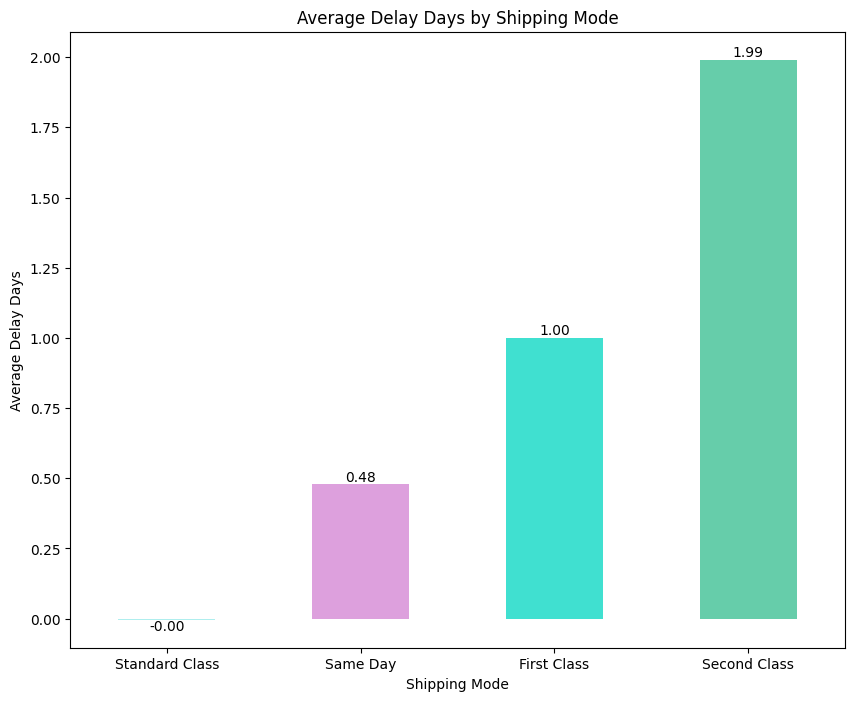

In [ ]:
d=df.groupby('Shipping Mode')['Delay Days'].mean().sort_values().plot(kind='bar',figsize=(10,8),color=['paleturquoise','plum','turquoise','mediumaquamarine'])
for c in d.containers:
  d.bar_label(c, fmt='%.2f')
plt.xticks(rotation=0)
plt.title('Average Delay Days by Shipping Mode')
plt.ylabel('Average Delay Days')
plt.show()

**INSIGHTS:**
- Second Class has the highest average delay (1.99 days), making it the least efficient shipping mode.
- Standard Class shows almost zero delay, indicating the most consistent delivery performance.
- Premium shipping modes (First Class and Second Class) experience higher delays due to stricter delivery commitments.
- Standard Class benefits from more flexible delivery schedules, reducing the likelihood of delays.
- Increasing shipment volumes may further impact the performance of premium shipping services.
- Improve or redesign Second Class shipping to reduce delays and enhance service reliability.
- Address operational issues in Same Day delivery through better route planning and resource allocation

**5. Analyze the relationship between logistics operations, sales performance, and profitability.**

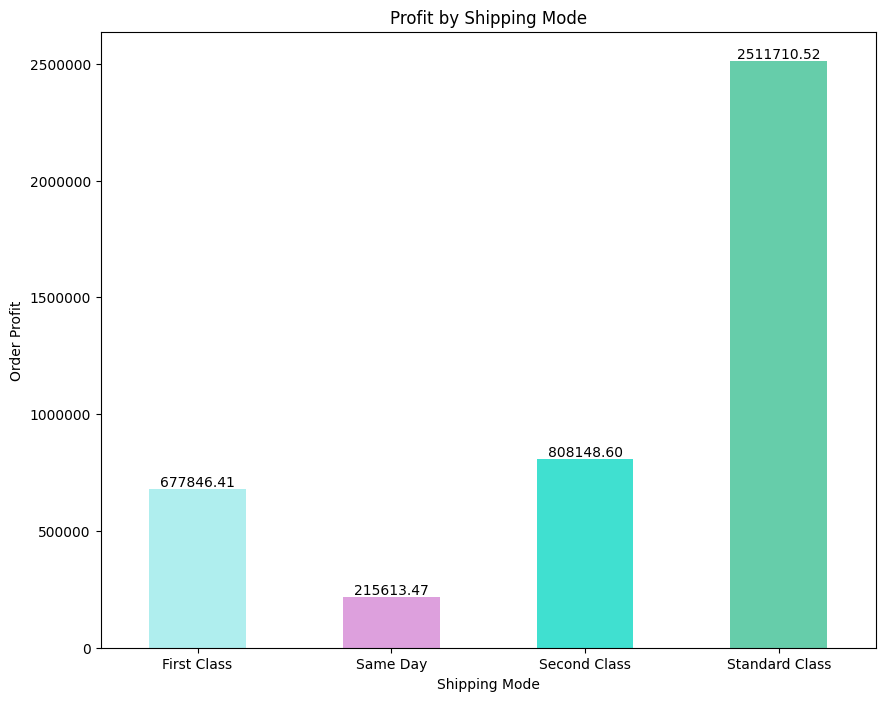

In [ ]:
e=df.groupby('Shipping Mode')['Order Profit Per Order'].sum().plot(kind='bar',figsize=(10,8),color=['paleturquoise','plum','turquoise','mediumaquamarine'])
for c in e.containers:
  e.bar_label(c,fmt='%.2f')
plt.ticklabel_format(style='plain',axis='y')
plt.title('Profit by Shipping Mode')
plt.ylabel('Order Profit')
plt.xticks(rotation=0)
plt.show()

**INSIGHTS:**
- Standard Class generated the highest profit, contributing the majority of total profit among all shipping modes.
- Same Day shipping generated the lowest profit compared to other shipping modes.
- Profitability varies significantly across different shipping methods.
- The high profit from Standard Class suggests strong customer adoption and efficient cost management.
- Same Day shipping appears to have lower profit margins despite offering faster delivery.
- Standard Class is the primary contributor to overall logistics profitability.
- Shipping modes with longer delivery windows generally contribute more profit than expedited shipping options.
- Optimizing the mix of shipping modes could further improve overall business profitability.

In [ ]:
df.groupby('Delivery Status')['Order Profit Per Order'].sum().round(2)

,Order Profit Per Order
Delivery Status,
Advance Shipping,984425.78
Late Delivery,2283704.54
Shipping Canceled,173875.32
Shipping On Time,771313.36


In [ ]:
print(df['Delivery Status'].unique())

['Advance Shipping' 'Late Delivery' 'Shipping On Time' 'Shipping Canceled']


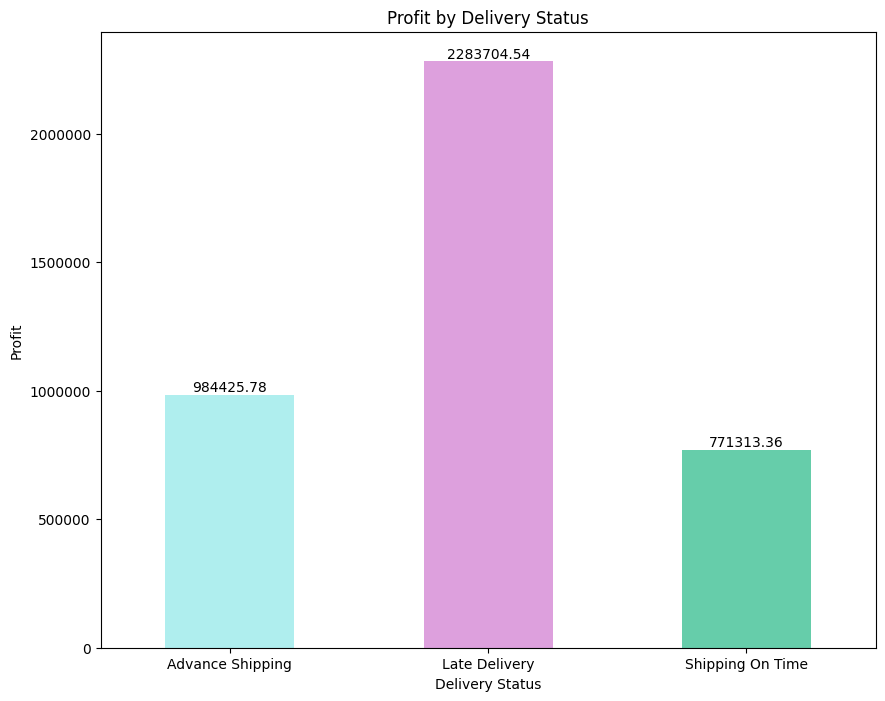

In [ ]:
profit_status = df.groupby('Delivery Status')['Order Profit Per Order'].sum()

profit_chart = profit_status[profit_status.index != 'Shipping Canceled']

f = profit_chart.plot(
    kind='bar',
    figsize=(10,8),
    color=['paleturquoise','plum','mediumaquamarine']
)

for c in f.containers:
    f.bar_label(c, fmt='%.2f')

plt.ticklabel_format(style='plain', axis='y')
plt.title('Profit by Delivery Status')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()

**INSIGHTS:**
- Late Delivery shows the highest profit, mainly because a large number of orders fall into this category, not because delayed deliveries are more efficient.
- Improving delivery performance may shift profits from the Late Delivery category to the On-Time Delivery category while maintaining overall profitability.
- Reducing order cancellations and increasing advance shipping capacity can help improve customer satisfaction and support sustainable profit growth.
- All records, including canceled shipments, were retained in the dataset to ensure that the analysis reflects the overall logistics and delivery performance.

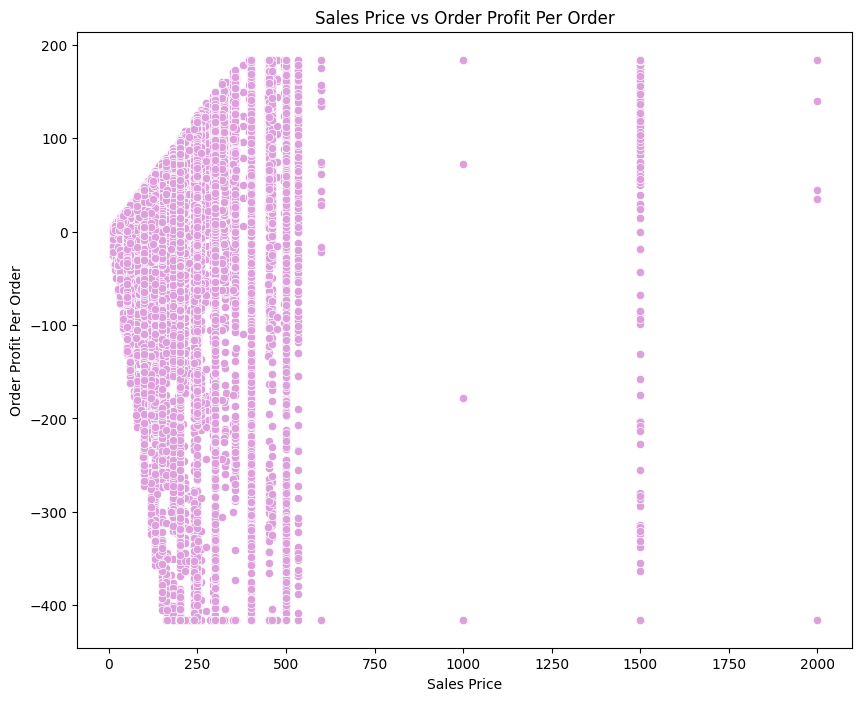

In [ ]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='Sales Price',y='Order Profit Per Order',color='plum')
plt.title('Sales Price vs Order Profit Per Order')
plt.xlabel('Sales Price')
plt.ylabel('Order Profit Per Order')
plt.show()

**INSIGHTS:**
- Orders with sales price below 500 show negative profit per order (between -400 and 0).
- The highest profit per order (200) occurs at the highest sales price (2000).
- Low-price orders (<500) likely have fixed logistics costs (packing, shipping, handling) that exceed the gross margin(per-order loss).
- High-price orders (>750) seem to have better margin structures or higher - perceived value allowing cost recovery.
- If raise minimum sales price to 750, nearly all orders will be profitable per unit.
- Orders priced below 250 will likely continue losing 200–400 per order — these should be flagged as loss leaders.
- Investigate loss-making orders in the 500–750 range and optimize shipping and handling costs to improve profitability.
- Incentivize customers to buy above 750 — offer discounts or free upgrades at that threshold to shift volume into profitable zone.

In [ ]:
df.columns

Index(['Transaction Type', 'Days For Shipping (Real)',
       'Days For Shipment (Scheduled)', 'Delivery Status',
       'Late Delivery Risk', 'Category Name', 'Customer City',
       'Customer Segment', 'Customer State', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Date', 'Order Id',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales Price',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order Status', 'Product Name', 'Product Price', 'Shipping Date',
       'Shipping Mode', 'Delay Days'],
      dtype='object')

**6.Discover top-performing apparel categories and high-demand markets based on shipment data.**

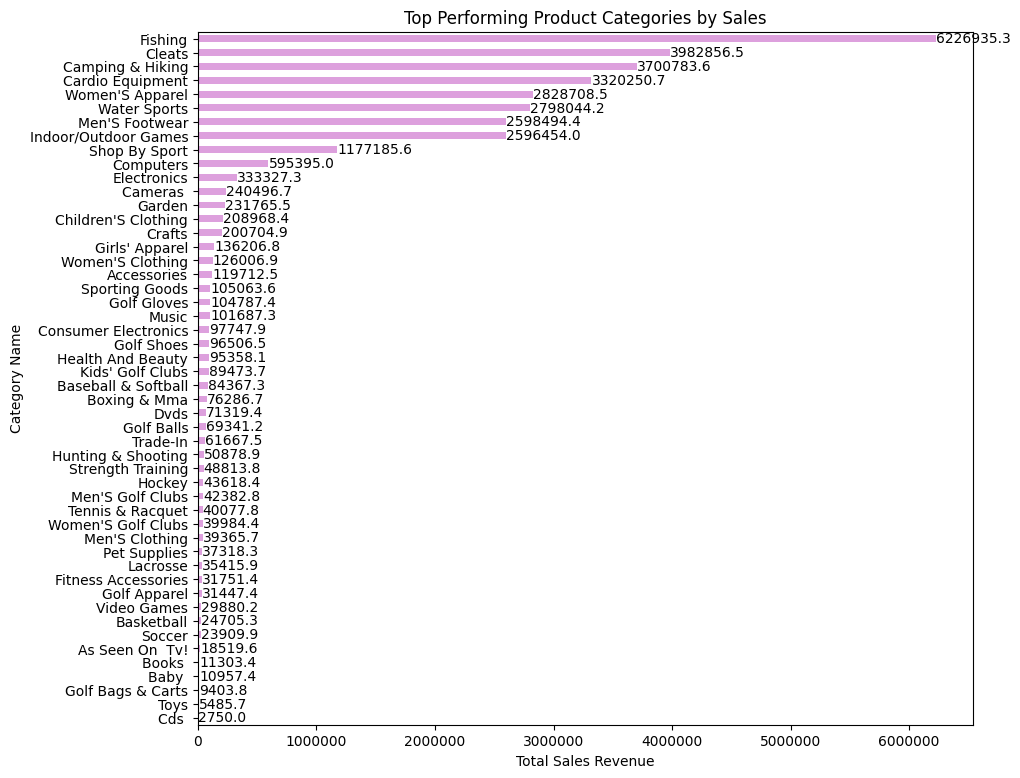

In [ ]:
f=df.groupby('Category Name')['Order Item Total'].sum().sort_values().plot(kind='barh',figsize=(10,9),color='plum')
for c in f.containers:
  f.bar_label(c,fmt='%.1f')
plt.ticklabel_format(style='plain',axis='x')
plt.title('Top Performing Product Categories by Sales')
plt.xlabel('Total Sales Revenue')
plt.ylabel('Category Name')
plt.show()

**INSIGHTS:**
- Fishing is the top-performing category, generating over 6.22M in sales, followed by Cleats and Camping & Hiking.
- Toys and CDs are the lowest-performing categories, contributing only a small share of total revenue.
- Outdoor and sports-related categories significantly outperform other product segments, indicating strong customer demand.
- Sales are highly concentrated in a few categories, particularly Fishing, resulting in an uneven revenue distribution.
- Revenue may be vulnerable to fluctuations in Fishing sales due to its dominant contribution.
- Low-performing categories such as CDs and Toys are likely to continue declining without strategic intervention.
- Focus marketing and inventory investments on high-performing categories such as Fishing, Cleats, and Camping & Hiking.
- Implement promotional campaigns or clearance strategies to improve turnover of low-performing categories.

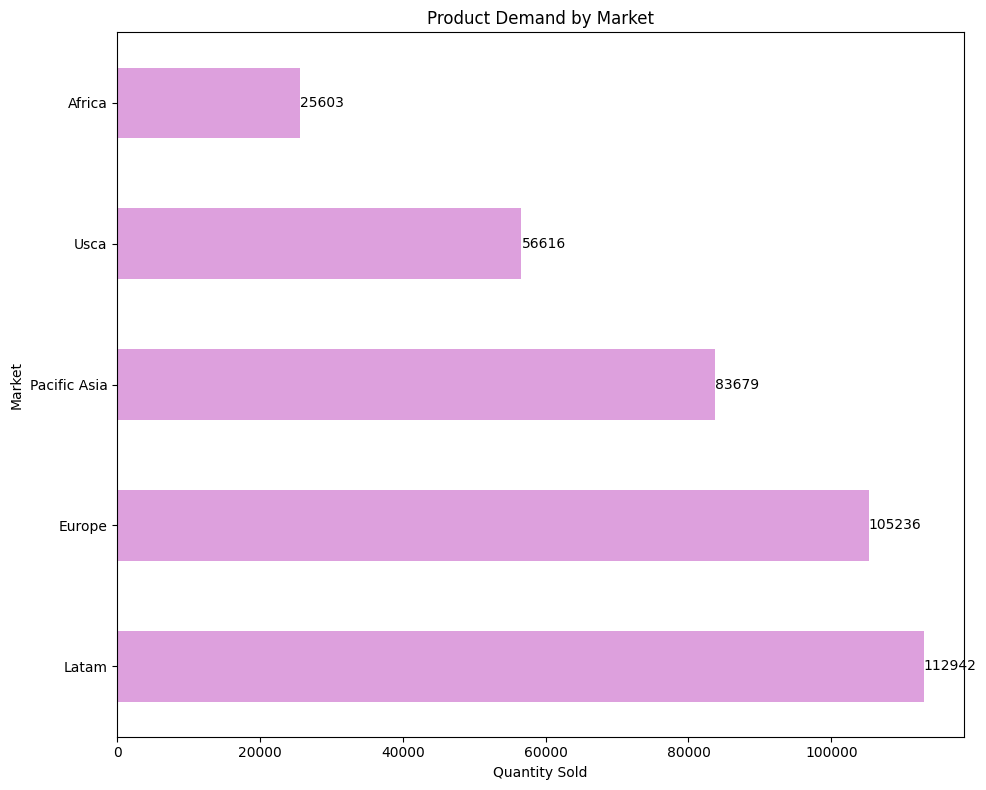

In [ ]:
market_sales = df.groupby('Market')['Order Item Quantity'].sum().sort_values(ascending=False)
g=market_sales.plot(kind='barh',figsize=(10,8),color='plum')
for c in g.containers:
  g.bar_label(c)
plt.title('Product Demand by Market')
plt.xlabel('Quantity Sold')
plt.tight_layout()
plt.show()

**INSIGHTS:**
- Latam and Europe are the highest-demand markets, contributing the largest share of total units sold.
- Africa and Usca record the lowest sales volumes, indicating relatively weaker market performance.
- Sales are heavily concentrated in a few regions, particularly Latam and Europe.
- Lower demand in Africa and Usca may indicate market penetration challenges or stronger competition.
- Latam and Europe are likely to remain the primary contributors to overall sales volume.
- Without targeted growth strategies, lower-performing regions may continue to lag behind other markets.
- Prioritize inventory and logistics resources in high-demand regions to maintain service levels and prevent stock shortages.
- Develop region-specific marketing and pricing strategies to improve sales performance in underperforming markets.

**7. Monitor delivery status and identify patterns in delayed, cancelled, and completed shipments.**

In [ ]:
df['Delivery Status'].value_counts()

,count
Delivery Status,
Late Delivery,98976
Advance Shipping,41592
Shipping On Time,32194
Shipping Canceled,7754


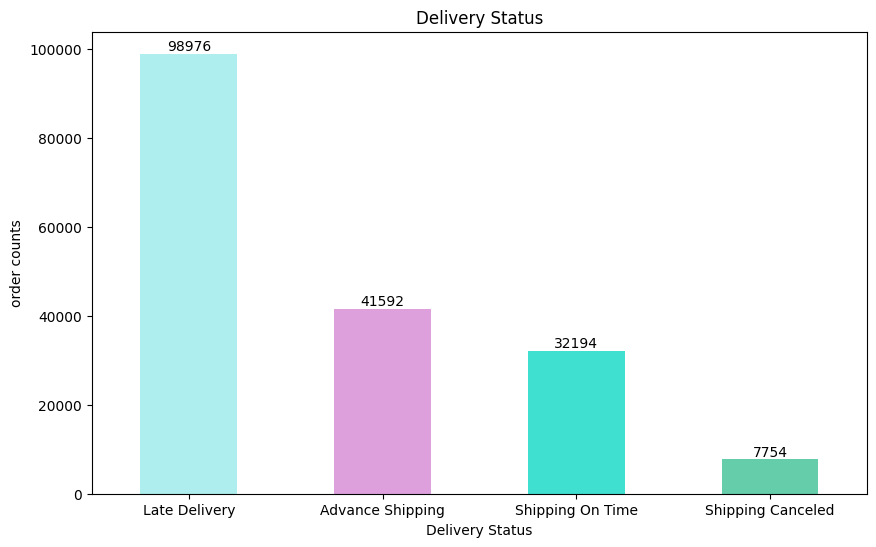

In [ ]:
h=df['Delivery Status'].value_counts().plot(kind='bar',figsize=(10,6),color=['paleturquoise','plum','turquoise','mediumaquamarine'])
for c in h.containers:
  h.bar_label(c)
plt.xticks(rotation=0)
plt.ylabel('order counts')
plt.title('Delivery Status')
plt.show()

**INSIGHTS:**
- Late Delivery is the most common delivery status, followed by Advance Shipping.
- On-Time Delivery accounts for a smaller share of orders, while Shipping Canceled is the least frequent status.
- A high number of late deliveries suggests inefficiencies in the logistics and fulfillment process.
- The gap between late and on-time deliveries indicates opportunities to improve delivery reliability.
- If current trends continue, late deliveries are likely to remain the dominant delivery status.
- Improving logistics performance could increase the share of on-time deliveries and reduce cancellations.

**8. Analyze monthly and seasonal shipment trends to understand logistics demand patterns.**



In [ ]:
df['Month'] = df['Shipping Date'].dt.month_name()

df['Quarter'] = df['Shipping Date'].dt.quarter

In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_orders = df.groupby('Month')['Order Id'].count()
monthly_orders = monthly_orders.reindex(month_order)

print(monthly_orders)
print("\nTotal Orders:", monthly_orders.sum())



Month
January      17404
February     14831
March        15886
April        15451
May          15843
June         15282
July         15954
August       15789
September    15539
October      13292
November     12475
December     12770
Name: Order Id, dtype: int64

Total Orders: 180516


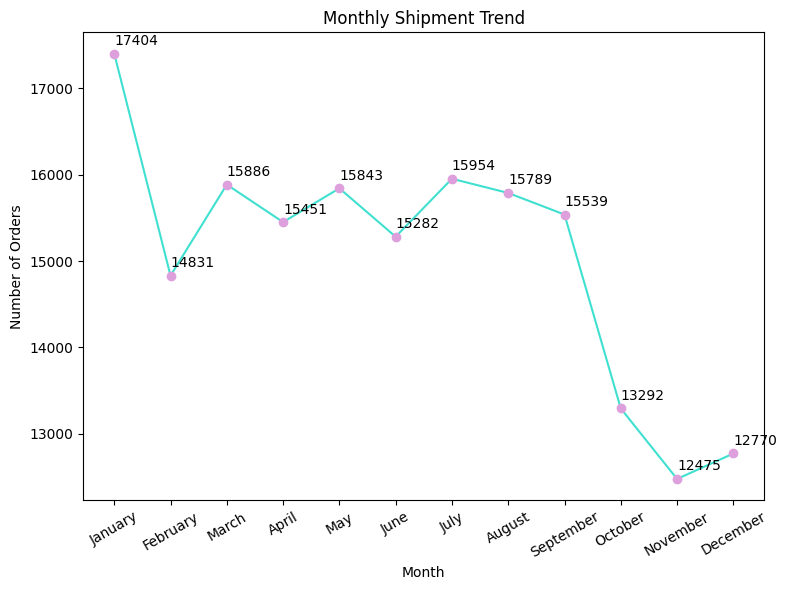

In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December']
monthly_orders = df.groupby(df['Shipping Date'].dt.month)['Order Id'].count()

plt.figure(figsize=(8, 6))
j = monthly_orders.plot(kind='line', marker='o',color='turquoise',
markerfacecolor='plum',markeredgecolor='plum')

plt.xticks(ticks=range(1, 13), labels=month_order, rotation=30)

for i, v in zip(monthly_orders.index, monthly_orders.values):
    plt.text(i, v + 99 , str(v), ha='left')
plt.title('Monthly Shipment Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


**INSIGHTS:**
- January records the highest order volume, while November has the lowest.
- Order volume remains relatively stable during most of the year before declining in the final quarter.
- The decline after January suggests seasonal variations in customer demand.
- The significant drop in Q4 may indicate reduced demand, inventory constraints, or weaker promotional activity.
- Order volumes are likely to remain highest at the beginning of the year if historical trends continue.
- Without intervention, lower order volumes may persist during the final months of the year.
- Plan inventory and logistics capacity in advance to accommodate peak demand periods.
- Implement targeted promotions and sales campaigns during low-volume months to improve order demand.

In [ ]:
def shipment_season(month):
  if month in [12,1,2]:
    return 'Winter'
  elif month in [3,4,5]:
    return 'Spring'
  elif month in [6,7,8]:
    return 'Summer'
  else:
    return 'Autumn'

In [ ]:
df['Season']=df['Shipping Date'].dt.month.apply(shipment_season)

In [ ]:
df.groupby('Season')['Shipping Date'].count().sort_values()

,Shipping Date
Season,
Autumn,41306
Winter,45005
Summer,47025
Spring,47180


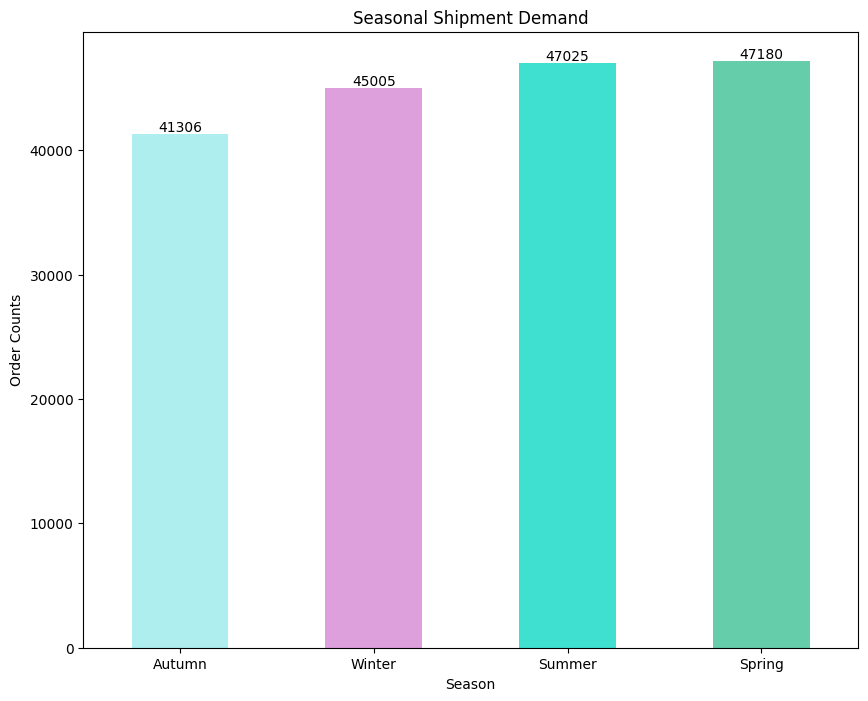

In [ ]:
k=df.groupby('Season')['Shipping Date'].count().sort_values().plot(kind='bar',figsize=(10,8),color=['paleturquoise','plum','turquoise','mediumaquamarine'])
for c in k.containers:
  k.bar_label(c)
plt.title('Seasonal Shipment Demand')
plt.ylabel('Order Counts')
plt.xticks(rotation=0)
plt.show()

**INSIGHTS:**
- Spring and Summer record the highest shipment volumes, indicating strong seasonal demand.
- Autumn has the lowest shipment volume, while Winter maintains moderate demand levels.
- Customer demand is higher during warmer seasons, leading to increased shipment activity in Spring and Summer.
- The lower volume in Autumn suggests a temporary decline in demand before Winter sales activity begins.
- Spring and Summer are likely to remain the busiest seasons for shipments in future periods.
- Autumn may continue to experience relatively lower shipment volumes if current trends persist.
- Allocate additional logistics and inventory resources during Spring and Summer to handle higher demand.
- Introduce targeted promotions during Autumn to improve order volumes and maintain consistent sales throughout the year.

**9. Analyze the contribution of different customer segments to overall sales.**

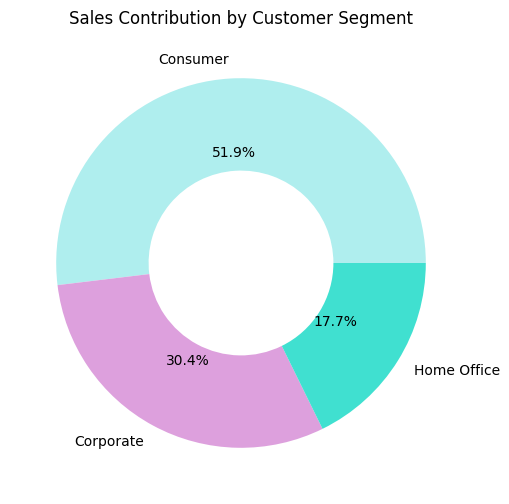

In [ ]:
segment_sales = df.groupby('Customer Segment')['Sales Price'].sum()

plt.figure(figsize=(6,6))

plt.pie(segment_sales,labels=segment_sales.index,autopct='%1.1f%%',
    wedgeprops={'width':0.5},colors=['paleturquoise','plum','turquoise','mediumaquamarine'])

plt.title('Sales Contribution by Customer Segment')

plt.show()

**INSIGHTS:**
- Consumer customers generate the highest sales contribution (51.9%), making them the primary revenue-driving segment.
- Corporate (30.4%) and Home Office (17.7%) segments contribute smaller shares, indicating lower sales participation compared to Consumer customers.
- Consumer customers likely place more frequent orders, resulting in a larger share of total sales.
- Home Office customers contribute the least sales, suggesting lower demand or fewer purchases compared to other segments.
- The Consumer segment is expected to remain the leading revenue contributor if current purchasing patterns continue.
- Corporate customers have growth potential, as a modest increase in demand could significantly boost overall sales.
- Focus marketing and retention efforts on Consumer customers to sustain the largest source of revenue.
- Introduce targeted promotions for Corporate and Home Office segments to increase their sales contribution and diversify revenue sources.

**10.Analyze the impact of customer transaction types on order volume and shipment demand**

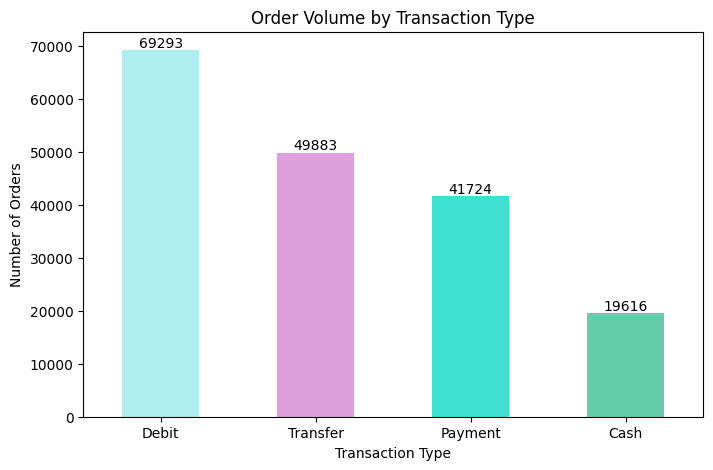

In [ ]:
m=df.groupby('Transaction Type')['Order Id'].count().sort_values(ascending=False).plot(kind='bar',figsize=(8,5),color=['paleturquoise','plum','turquoise','mediumaquamarine'])
for c in m.containers:
  m.bar_label(c)
plt.title('Order Volume by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

**INSIGHTS:**

- Debit is the most preferred transaction type accounting for the largest share of all transactions.
- Cash transactions contribute the least indicating lower customer preference for cash payments.
- Customers may prefer Debit payments due to convenience and widespread acceptance, resulting in the highest transaction share.
- The lower Cash usage suggests a shift toward digital payment methods, reducing dependence on traditional payment options.
- Debit transactions are likely to remain the dominant payment method if current customer payment behavior continues.
- Digital payment methods (Debit and Transfer) are expected to increase further, while Cash usage may continue to decline.
- Enhance digital payment infrastructure and customer experience to support the most frequently used transaction methods.
- Encourage Transfer and Cash users to adopt digital payment channels through incentives, discounts, or loyalty rewards.

In [ ]:
df.to_csv('Product_Logistic_and_Shipment_dataset.csv', index=False)


In [ ]:
from google.colab import files
files.download('Product_Logistic_and_Shipment_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###**Documentation, Insights and Presentation**

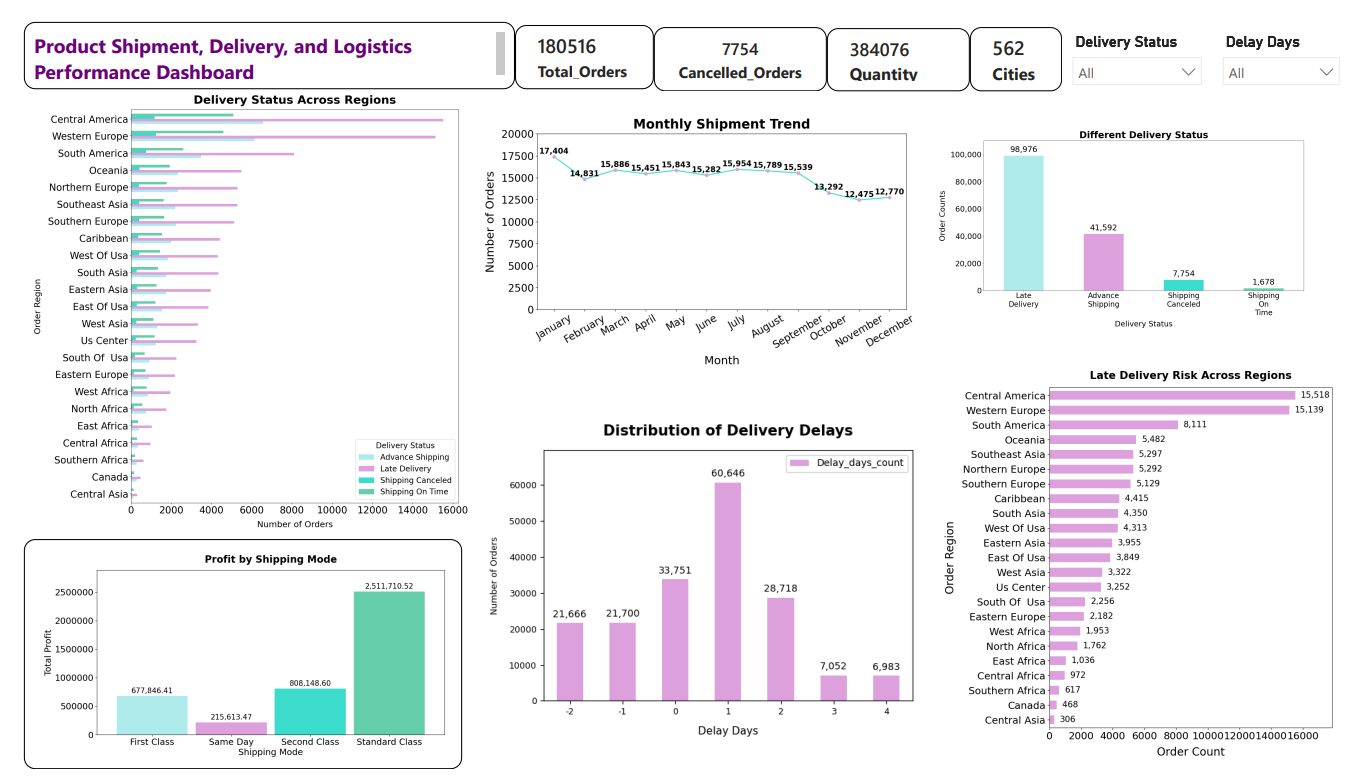

**Documentation**

In [ ]:
https://drive.google.com/drive/folders/1E9FMddDYnSlVGatFjA8Q-rNUqfc7dzBy?usp=sharing

SyntaxError: invalid decimal literal (1915250573.py, line 1)

**Insights:**
- Late deliveries account for 54.8% of total orders (98,976 orders), making delivery delays the most critical logistics challenge.
- The company successfully managed 180,516 orders and shipped 384,076 units across 562 cities, demonstrating a large-scale logistics network.
- Central America and Western Europe are the highest shipment-contributing regions but also experience the highest late-delivery risks, indicating operational bottlenecks.
- Standard Class shipping generated the highest profit ($2.51M), making it the most profitable and efficient shipping mode.
- Shipment volume showed a downward trend from September onwards, suggesting seasonal fluctuations or supply chain constraints.
- Most delayed orders experienced only a 1-day delay (60,646 orders), indicating that small process improvements could significantly improve delivery performance.
- Order cancellations reached 7,754 orders, highlighting the need for improved delivery reliability and customer satisfaction initiatives.
- High shipment volumes in key regions are directly associated with increased delivery delays, suggesting insufficient logistics capacity and resource allocation.
- If current delivery performance continues, customer satisfaction, repeat purchases, and overall profitability may decline due to persistent late deliveries.
- Optimizing delivery routes, strengthening logistics infrastructure in high-risk regions, and improving demand forecasting can significantly reduce delays and improve operational efficiency.

**Conclusion**
- The company operates a strong logistics network, successfully managing 180,516 orders and 384,076 shipped units across 562 cities.
- Late deliveries (54.8%) are the primary operational challenge and require immediate attention to improve service performance.
- Central America and Western Europe are key business regions but experience the highest delivery delays and logistics risks.
- Standard Class shipping is the most profitable shipping mode and plays a major role in overall business profitability.
- Improving delivery efficiency, route optimization, and logistics planning can significantly enhance customer satisfaction, reduce cancellations, and support sustainable business growth.